<h1 style="text-align: center;">Lab 2 - Complejidad y búsqueda de hiperparámetros</h1>

### Integrantes:
**1. Juan José Scovino Villarreal 202421005**<br>
**2. Gabriel Ramírez Barros 202422096**

### Contexto

En el Laboratorio 1 se construyó para AlpesPlanck un primer modelo de regresión lineal
que estima la temperatura máxima del día siguiente a partir de las mediciones diarias de
la estación de Jena. El mejor de los dos modelos (Estrategia B, resolución mensual) llegó
a un RMSE de 4,18 °C y un R² de 0,77 sobre el conjunto de prueba.

En este laboratorio el objetivo es distinto: ya no se trata de limpiar ni de explorar,
sino de responder si ese desempeño puede mejorarse aumentando la complejidad del modelo,
y hasta dónde conviene hacerlo. Se evalúan regresión polinomial, regresión regularizada
(Ridge y Lasso) y su combinación, se busca de forma sistemática el valor de los
hiperparámetros mediante validación cruzada, y se cuantifica la incertidumbre del
desempeño mediante bootstrapping.

### Punto de partida

| Elemento | Valor | Origen |
|---|---|---|
| Conjunto de datos | `Datos_Lab_1_limpio.csv` | Actividad 2 del Laboratorio 1 |
| Variable objetivo | `temp_max_manana` | Temperatura máxima del día siguiente (°C) |
| Métrica principal | RMSE | Está en grados, es directamente interpretable |
| Métricas complementarias | MAE, R² | Exigidas por el enunciado |
| Modelo de referencia | Regresión lineal, Estrategia B | RMSE 4,18 °C / R² 0,77 en test (Lab 1) |
| Partición | `test_size=0.25`, `random_state=42` | La misma del Lab 1, para que las cifras sean comparables |

## 1. Importación de las librerías

Se mantienen las librerías del Laboratorio 1 y se agregan las que introducen las
prácticas 5 y 6: `PolynomialFeatures` para la expansión polinomial, `Ridge` y `Lasso`
para la regularización, `GridSearchCV` y `KFold` para la búsqueda de hiperparámetros
con validación cruzada, `validation_curve` para las curvas de complejidad y `resample`
para el bootstrapping.

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, KFold, validation_curve
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.utils import resample

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

print("Librerias importadas correctamente")

Librerias importadas correctamente


## 2. Carga de los datos

Se carga el conjunto que quedó al final de la Actividad 2 del Laboratorio 1, ya
corregido en las cuatro dimensiones de calidad: unicidad, consistencia, validez y
completitud de la variable objetivo. Los valores faltantes de las variables
predictoras siguen presentes de forma deliberada, porque se imputan dentro del
pipeline para evitar fuga de datos.

In [35]:
data = pd.read_csv('Datos_Lab_1_limpio.csv')

print(f"Conjunto limpio: {data.shape[0]} filas x {data.shape[1]} columnas")
print()
print(f"Nulos en la variable objetivo : {data['temp_max_manana'].isnull().sum()}")
print(f"Fechas repetidas              : {data['fecha'].duplicated().sum()}")
print(f"Categorias en mes             : {data['mes'].nunique()}")
print(f"Categorias en sector_viento   : {data['sector_viento'].nunique()}")
print(f"Rango de temp_max_manana      : {data['temp_max_manana'].min():.2f} a {data['temp_max_manana'].max():.2f} °C")
print(f"Desviacion estandar objetivo  : {data['temp_max_manana'].std():.2f} °C")

Conjunto limpio: 2393 filas x 27 columnas

Nulos en la variable objetivo : 0
Fechas repetidas              : 0
Categorias en mes             : 12
Categorias en sector_viento   : 8
Rango de temp_max_manana      : -15.23 a 37.01 °C
Desviacion estandar objetivo  : 8.99 °C


## 3. Partición de los datos

Usamos la misma partición del Laboratorio 1: `test_size=0.25` y `random_state=42`.
Lo hacemos así a propósito, porque queremos comparar los modelos de este laboratorio
contra el RMSE de 4,18 °C que nos dio la regresión lineal. Si cambiáramos la semilla,
los conjuntos serían otros y no sabríamos si una diferencia en el error viene del
modelo nuevo o simplemente de que le tocaron días más fáciles.

De aquí en adelante no volvemos a tocar el conjunto de prueba hasta el final. Toda la
búsqueda del grado del polinomio y de los alphas se hace con validación cruzada, pero
solo sobre entrenamiento. La razón es que si usamos el test para escoger los
hiperparámetros, después ese mismo test ya no sirve para saber qué tan bien generaliza
el modelo, porque de alguna forma ya lo tuvimos en cuenta al elegir.

In [36]:
objetivo = 'temp_max_manana'

X = data.drop(columns=[objetivo])
y = data[objetivo]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# Un unico esquema de validacion cruzada compartido por TODOS los modelos del laboratorio.
# Es lo que hace comparables sus desviaciones estandar en la Actividad 5.
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

print(f"Entrenamiento: {X_train.shape[0]} filas ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Prueba       : {X_test.shape[0]} filas ({X_test.shape[0]/len(X)*100:.1f}%)")
print()
print("Validacion cruzada: KFold(n_splits=5, shuffle=True, random_state=42)")

Entrenamiento: 1794 filas (75.0%)
Prueba       : 599 filas (25.0%)

Validacion cruzada: KFold(n_splits=5, shuffle=True, random_state=42)


## 4. Definición de las variables del modelo

Se retoman las listas justificadas en la Actividad 2 del Laboratorio 1. Se conserva la
Estrategia B (resolución mensual), que fue la seleccionada allí por tener menor RMSE y
mayor R², y se mantiene fija durante todo este laboratorio. La razón es metodológica:
lo que se quiere medir aquí es el efecto de la complejidad y de la regularización, y si
además cambiara la representación temporal no sería posible atribuir las diferencias a
una causa u otra.

Las cuatro variables excluidas se mantienen excluidas por los mismos motivos del
Laboratorio 1: `fecha` es un identificador, `anio` obligaría a extrapolar fuera del
rango observado, `dia_del_anio` tiene una relación con forma de campana que la
regresión lineal no puede representar en su forma cruda, y `registros_del_dia` es un
metadato del proceso de captura.

In [37]:
variables_numericas = [
    'presion_media', 'presion_min', 'presion_max', 'presion_desv',
    'humedad_media', 'humedad_min', 'humedad_max', 'humedad_desv',
    'viento_media', 'viento_min', 'viento_max', 'viento_desv',
    'rafaga_media', 'rafaga_min', 'rafaga_max', 'rafaga_desv',
    'viento_norte', 'viento_este', 'direccion_viento'
]

variables_categoricas = ['mes', 'sector_viento']

variables_excluidas = ['fecha', 'anio', 'dia_del_anio', 'registros_del_dia']

print(f"Variables numericas  : {len(variables_numericas)}")
print(f"Variables categoricas: {variables_categoricas}")
print(f"Excluidas del modelo : {variables_excluidas}")
print()
print("Columnas que ve el modelo lineal tras One-Hot:",
      len(variables_numericas) + data['mes'].nunique() + data['sector_viento'].nunique())

Variables numericas  : 19
Variables categoricas: ['mes', 'sector_viento']
Excluidas del modelo : ['fecha', 'anio', 'dia_del_anio', 'registros_del_dia']

Columnas que ve el modelo lineal tras One-Hot: 39


## 5. Función de evaluación

Todas las actividades reportan las mismas tres métricas exigidas por el enunciado
(RMSE, MAE y R²), así que se define una sola función y se reutiliza. Es la misma
estructura de las prácticas 5 y 6, donde las tres métricas se imprimen juntas después
de cada `predict`.

In [38]:
def calcular_metricas(y_real, y_predicho):
    """Devuelve las tres metricas que exige el enunciado, en un diccionario."""
    return {
        'RMSE': np.sqrt(mean_squared_error(y_real, y_predicho)),
        'MAE': mean_absolute_error(y_real, y_predicho),
        'R2': r2_score(y_real, y_predicho)
    }


def reporte(nombre, modelo, X_tr, y_tr, X_te, y_te):
    """Imprime metricas en entrenamiento y prueba y devuelve el DataFrame."""
    tabla = pd.DataFrame({
        'Entrenamiento': calcular_metricas(y_tr, modelo.predict(X_tr)),
        'Prueba': calcular_metricas(y_te, modelo.predict(X_te))
    }).T
    print(f"=== {nombre} ===")
    print(tabla.round(4))
    return tabla


# --- Modelo de referencia: regresion lineal sin regularizacion (Estrategia B del Lab 1) ---
numeric_lineal = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocesamiento_lineal = ColumnTransformer(transformers=[
    ("num", numeric_lineal, variables_numericas),
    ("cat", categorical_transformer, variables_categoricas),
])

modelo_lineal = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento_lineal),
    ("modelo", LinearRegression()),
])

modelo_lineal.fit(X_train, y_train)
metricas_lineal = reporte("REFERENCIA — Regresion lineal sin regularizacion (Lab 1)",
                          modelo_lineal, X_train, y_train, X_test, y_test)

=== REFERENCIA — Regresion lineal sin regularizacion (Lab 1) ===
                 RMSE     MAE      R2
Entrenamiento  4.3043  3.4304  0.7762
Prueba         4.1761  3.3364  0.7661


# Actividad 1 - Modelo de regresión polinomial

En el Laboratorio 1 el modelo fue una regresión lineal sobre las variables originales,
y en el análisis exploratorio ya habíamos visto que varias relaciones del conjunto no
son lineales. La regresión polinomial es la forma de atacar eso: no cambiamos de
algoritmo, sino que transformamos las variables de entrada agregando sus potencias y
los productos entre ellas, y después ajustamos la misma regresión lineal de siempre.
El modelo sigue siendo lineal en sus parámetros, lo que cambia es la forma que puede
tomar la curva ajustada.

El costo de eso es que el número de parámetros crece muy rápido. Con nuestras 19
variables numéricas, pasar de grado 1 a grado 3 lleva el modelo de 39 a más de 1.500
coeficientes, y solo tenemos 1.794 filas de entrenamiento. Por eso el objetivo de esta
actividad no es simplemente "subirle el grado", sino encontrar hasta dónde conviene
subirlo, y ver a partir de qué punto el modelo empieza a memorizar en vez de aprender.

Para eso usamos GridSearchCV, que entrena un modelo por cada combinación de
hiperparámetros y los evalúa con validación cruzada sobre el conjunto de
entrenamiento. Exploramos dos hiperparámetros: el grado del polinomio y la estrategia
de escalamiento.

## 1.1 Construcción del pipeline polinomial

El pipeline mantiene la estructura del Laboratorio 1 y le agrega un paso nuevo en la
rama numérica:

| Rama | Pasos |
|---|---|
| Numérica (19 variables) | Imputación por mediana → escalado → expansión polinomial |
| Categórica (`mes`, `sector_viento`) | Imputación por moda → One-Hot |
| Modelo | Regresión lineal |

Dos decisiones sobre este pipeline:

**El escalado va antes de la expansión polinomial.** Si no, las potencias
amplificarían las diferencias de magnitud entre variables: `presion_media` ronda los
1.000 hPa y `viento_media` los 3 m/s, así que al elevarlas al cuadrado quedarían en
1.000.000 contra 9. Escalando primero, todas las variables entran a la expansión en
condiciones comparables.

**La expansión se aplica solo a las variables numéricas.** No tiene sentido elevar al
cuadrado una columna binaria de One-Hot, porque 0² = 0 y 1² = 1: generaría columnas
idénticas a las originales y produciría colinealidad perfecta.

**Se usa `include_bias=False`.** Por defecto `PolynomialFeatures` agrega una columna
de unos, pero `LinearRegression` ya estima su propio intercepto. Dejarla crearía una
columna redundante, que es justamente el tipo de colinealidad que detectamos con el
VIF en la Actividad 5 del Laboratorio 1.

In [39]:
numeric_polinomial = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("polynomial", PolynomialFeatures(degree=2, include_bias=False)),
])

preprocesamiento_polinomial = ColumnTransformer(transformers=[
    ("num", numeric_polinomial, variables_numericas),
    ("cat", categorical_transformer, variables_categoricas),
])

pipeline_polinomial = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento_polinomial),
    ("modelo", LinearRegression()),
])

pipeline_polinomial

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocesamiento', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3I

## 1.2 Cuánto crece la complejidad con el grado

Antes de buscar el mejor grado, conviene ver el tamaño que tendría el modelo en cada
caso. Una medida directa de la complejidad de un modelo es el número de parámetros
que ajusta.

In [40]:
filas_complejidad = []
for g in [1, 2, 3]:
    pipe = Pipeline(steps=[
        ("preprocesamiento", ColumnTransformer(transformers=[
            ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                              ("scaler", StandardScaler()),
                              ("polynomial", PolynomialFeatures(degree=g, include_bias=False))]),
             variables_numericas),
            ("cat", categorical_transformer, variables_categoricas),
        ])),
        ("modelo", LinearRegression()),
    ])
    pipe.fit(X_train, y_train)
    n_coef = len(pipe.named_steps["modelo"].coef_)
    filas_complejidad.append({
        'Grado': g,
        'Coeficientes del modelo': n_coef,
        'Filas de entrenamiento': X_train.shape[0],
        'Observaciones por parametro': round(X_train.shape[0] / n_coef, 2)
    })

tabla_complejidad = pd.DataFrame(filas_complejidad)
print(tabla_complejidad.to_string(index=False))

 Grado  Coeficientes del modelo  Filas de entrenamiento  Observaciones por parametro
     1                       39                    1794                        46.00
     2                      229                    1794                         7.83
     3                     1559                    1794                         1.15


## 1.3 Búsqueda de hiperparámetros con GridSearchCV

Definimos el espacio de búsqueda con dos hiperparámetros:

| Hiperparámetro | Valores explorados | Por qué |
|---|---|---|
| Grado del polinomio | 1, 2, 3 | El grado 1 equivale al modelo lineal del Laboratorio 1 y sirve de referencia dentro de la misma búsqueda. El 3 ya lleva el modelo a más de 1.500 coeficientes, así que es un techo razonable |
| Escalador | `StandardScaler`, `MinMaxScaler`, `RobustScaler` | En una regresión lineal simple el escalador no cambia las predicciones, pero al combinarse con la expansión polinomial sí, porque las potencias y productos se calculan sobre valores ya escalados y cada escalador los deja en un rango distinto |

Los nombres de las llaves del `param_grid` siguen la ruta del pipeline separada por
dobles guiones bajos: `preprocesamiento__num__polynomial__degree` significa "dentro
del paso `preprocesamiento`, en la rama `num`, en el transformador `polynomial`, el
parámetro `degree`".

Sobre la evaluación: `GridSearchCV` por defecto optimiza una sola métrica, pero el
enunciado pide reportar las tres. Por eso le pasamos un diccionario de métricas y le
indicamos con `refit="RMSE"` cuál se usa para elegir el ganador. Elegimos RMSE como
métrica principal por la misma razón del Laboratorio 1: está en grados y se
interpreta directamente.

Scikit-learn maximiza los puntajes, así que las métricas de error se registran
negadas (`neg_root_mean_squared_error`). Hay que multiplicarlas por −1 para leerlas.

La validación cruzada usa el objeto `kfold` definido al inicio, el mismo que usarán
todos los modelos del laboratorio.

In [41]:
param_grid_polinomial = {
    "preprocesamiento__num__polynomial__degree": [1, 2, 3],
    "preprocesamiento__num__scaler": [StandardScaler(), MinMaxScaler(), RobustScaler()],
}

metricas_cv = {
    'RMSE': 'neg_root_mean_squared_error',
    'MAE': 'neg_mean_absolute_error',
    'R2': 'r2',
}

grid_polinomial = GridSearchCV(
    estimator=pipeline_polinomial,
    param_grid=param_grid_polinomial,
    cv=kfold,
    scoring=metricas_cv,
    refit='RMSE',
    return_train_score=True,
    n_jobs=-1
)

print(f"Combinaciones a evaluar: "
      f"{len(param_grid_polinomial['preprocesamiento__num__polynomial__degree']) * len(param_grid_polinomial['preprocesamiento__num__scaler'])}")
print(f"Modelos que se entrenan : {9 * kfold.get_n_splits()}")

Combinaciones a evaluar: 9
Modelos que se entrenan : 45


In [42]:
%%time
grid_polinomial.fit(X_train, y_train)

print("Mejor configuracion:", grid_polinomial.best_params_)
print(f"Mejor RMSE en validacion cruzada: {-grid_polinomial.best_score_:.4f}")

Mejor configuracion: {'preprocesamiento__num__polynomial__degree': 1, 'preprocesamiento__num__scaler': StandardScaler()}
Mejor RMSE en validacion cruzada: 4.4053
CPU times: total: 422 ms
Wall time: 19.1 s


## 1.4 Resultados de la búsqueda

`GridSearchCV` guarda en `cv_results_` el desempeño de todas las combinaciones
evaluadas, no solo de la ganadora. Lo organizamos en una tabla para ver cómo se
comporta el error a medida que sube la complejidad, que es justamente lo que pide
analizar el enunciado.

Reportamos el promedio de los 5 pliegues y también su desviación estándar. La
desviación importa tanto como el promedio: mide qué tan consistente es el modelo
entre distintas particiones de los datos, y va a ser uno de los criterios de
selección en la Actividad 5.

In [43]:
resultados = pd.DataFrame(grid_polinomial.cv_results_)

tabla_grid = pd.DataFrame({
    'Grado': resultados['param_preprocesamiento__num__polynomial__degree'],
    'Escalador': [type(s).__name__ for s in resultados['param_preprocesamiento__num__scaler']],
    'RMSE_val': -resultados['mean_test_RMSE'],
    'RMSE_val_std': resultados['std_test_RMSE'],
    'MAE_val': -resultados['mean_test_MAE'],
    'R2_val': resultados['mean_test_R2'],
    'RMSE_train': -resultados['mean_train_RMSE'],
}).sort_values(['Grado', 'Escalador'])

tabla_grid['Brecha (val - train)'] = tabla_grid['RMSE_val'] - tabla_grid['RMSE_train']

print("=== Desempeno de todas las combinaciones (validacion cruzada, 5 pliegues) ===")
print(tabla_grid.round(4).to_string(index=False))

=== Desempeno de todas las combinaciones (validacion cruzada, 5 pliegues) ===
 Grado      Escalador  RMSE_val  RMSE_val_std  MAE_val      R2_val  RMSE_train  Brecha (val - train)
     1   MinMaxScaler    4.4053        0.2737   3.5174      0.7653      4.2918                0.1135
     1   RobustScaler    4.4053        0.2737   3.5174      0.7653      4.2918                0.1135
     1 StandardScaler    4.4053        0.2737   3.5174      0.7653      4.2918                0.1135
     2   MinMaxScaler    7.8084        3.6362   3.9667      0.0753      3.7474                4.0611
     2   RobustScaler    7.8084        3.6362   3.9667      0.0753      3.7474                4.0611
     2 StandardScaler    7.8084        3.6362   3.9667      0.0753      3.7474                4.0611
     3   MinMaxScaler  705.2995      600.7754  84.8499 -10384.0746      0.8422              704.4573
     3   RobustScaler  698.8898      803.0569  70.2795 -13469.6999      1.2756              697.6142
     3 Standa

## 1.5 Evaluación del mejor modelo polinomial sobre el conjunto de prueba

Recuperamos el mejor pipeline encontrado por la búsqueda y lo evaluamos sobre el
conjunto de prueba, que hasta este momento no había participado en nada. Comparamos
contra el modelo lineal de referencia.

In [44]:
mejor_polinomial = grid_polinomial.best_estimator_

metricas_polinomial = reporte("ACTIVIDAD 1 — Mejor modelo polinomial",
                              mejor_polinomial, X_train, y_train, X_test, y_test)

print()
print("Comparacion contra el modelo lineal de referencia (conjunto de PRUEBA):")
comparacion_a1 = pd.DataFrame({
    'Lineal sin regularizacion': metricas_lineal.loc['Prueba'],
    'Polinomial (mejor de la busqueda)': metricas_polinomial.loc['Prueba'],
}).T
print(comparacion_a1.round(4).to_string())

=== ACTIVIDAD 1 — Mejor modelo polinomial ===
                 RMSE     MAE      R2
Entrenamiento  4.3043  3.4304  0.7762
Prueba         4.1761  3.3364  0.7661

Comparacion contra el modelo lineal de referencia (conjunto de PRUEBA):
                                     RMSE     MAE      R2
Lineal sin regularizacion          4.1761  3.3364  0.7661
Polinomial (mejor de la busqueda)  4.1761  3.3364  0.7661


## 1.6 Análisis del efecto de la complejidad

La búsqueda terminó escogiendo el grado 1, o sea el modelo sin expansión polinomial,
que es el mismo que ya teníamos del Laboratorio 1 (RMSE 4,1761, MAE 3,3364, R² 0,7661
en prueba). Esperábamos otra cosa, porque en el Laboratorio 1 vimos que hay relaciones
que no son lineales, pero subir el grado no ayudó en nada.

| Grado | Coeficientes | Obs. por parámetro | RMSE entrenamiento | RMSE validación | Desv. est. | R² validación |
|---|---|---|---|---|---|---|
| 1 | 39 | 46,00 | 4,2918 | 4,4053 | 0,2737 | 0,7653 |
| 2 | 229 | 7,83 | 3,7474 | 7,8084 | 3,6362 | 0,0753 |
| 3 | 1.559 | 1,15 | 0,5408 | 872,44 | 723,13 | −16.086 |

Lo interesante es que los dos errores se van para lados contrarios. En entrenamiento el
error baja (4,29 → 3,75 → 0,54) y en validación sube (4,41 → 7,81 → 872,44). Mirando la
columna de observaciones por parámetro se entiende: en grado 3 quedan 1,15 filas por
cada coeficiente, casi un parámetro por dato, así que el modelo puede pasar por encima
de todos los puntos de entrenamiento. Ese RMSE de 0,54 no es que el modelo sea buenísimo,
es que se aprendió los datos de memoria.

El sobreajuste ya se ve desde el grado 2, el 3 solo lo exagera. La brecha entre
validación y entrenamiento se va de 0,11 a 4,06 grados, y el R² se cae a 0,0753. Para
tener una referencia: la desviación estándar de `temp_max_manana` es 8,99 °C, que sería
el error de predecir siempre el promedio, y el grado 2 da 7,81. O sea que casi no le
gana a no tener modelo.

La estabilidad se cae igual de rápido. La desviación entre los 5 pliegues pasa de 0,27 a
3,64 y después a 723,13. En grado 1 da casi lo mismo con cualquier partición, en grado 3
depende completamente de qué filas le tocaron. Es el sesgo-varianza que vimos en clase,
y por eso en la Actividad 5 no vamos a elegir el modelo mirando solo el promedio.

Sobre los escaladores, en grados 1 y 2 los tres dan exactamente el mismo número. Pensamos
que estaba mal, pero tiene explicación: los tres hacen algo de la forma x' = (x − a) / b,
solo cambia cómo calculan a y b, así que después de la expansión las columnas terminan
generando el mismo espacio y la regresión llega al mismo ajuste. Sin regularización da
igual cuál se use. Lo del grado 3 (705, 699, 872) tampoco significa que uno sea mejor,
eso es ruido de cálculo porque la matriz queda casi singular. Donde sí va a importar el
escalador es en las Actividades 3 y 4, porque Ridge y Lasso penalizan el tamaño de los
coeficientes y ahí la escala de las variables ya no es indiferente.

# Actividad 2 - Curvas de validación

En la actividad anterior la tabla del GridSearch ya mostraba que el error de validación
se dispara al subir el grado, pero con tres filas no se alcanza a ver bien la forma de
esa relación. La curva de validación grafica el error de entrenamiento y el de
validación en función del hiperparámetro que controla la complejidad, que aquí es el
grado del polinomio, y así se ve en qué punto exacto las dos curvas se separan.

Para esto usamos `validation_curve` de scikit-learn, que es la función que propone el
primer ejercicio de la práctica 5 justamente para este análisis. La diferencia con
`GridSearchCV` es que aquella explora combinaciones de varios hiperparámetros y
devuelve el mejor modelo, mientras que esta varía uno solo y devuelve la matriz
completa de puntajes, con un valor por cada combinación de grado y pliegue. Eso es lo
que necesitábamos, porque con la matriz completa podemos sacar no solo el error
promedio de cada grado sino también su desviación estándar entre pliegues, y así
graficar la variabilidad y no únicamente la línea del promedio.

Dejamos fijo el escalador en `StandardScaler`, que fue el que quedó de la búsqueda
anterior, y ampliamos el rango de grados a [1, 2, 3, 4] para ver hasta dónde sigue la
tendencia.

In [45]:
grados = [1, 2, 3, 4]

train_scores, val_scores = validation_curve(
    estimator=pipeline_polinomial,
    X=X_train,
    y=y_train,
    param_name="preprocesamiento__num__polynomial__degree",
    param_range=grados,
    cv=kfold,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

# scikit-learn maximiza puntajes, por eso el RMSE viene negado
train_rmse = -train_scores
val_rmse = -val_scores

train_media, train_desv = train_rmse.mean(axis=1), train_rmse.std(axis=1)
val_media, val_desv = val_rmse.mean(axis=1), val_rmse.std(axis=1)

curva = pd.DataFrame({
    'Grado': grados,
    'RMSE_train': train_media,
    'Desv_train': train_desv,
    'RMSE_val': val_media,
    'Desv_val': val_desv,
})
curva['Brecha'] = curva['RMSE_val'] - curva['RMSE_train']

print("=== Curva de validacion: RMSE por grado (5 pliegues) ===")
print(curva.round(4).to_string(index=False))

=== Curva de validacion: RMSE por grado (5 pliegues) ===
 Grado  RMSE_train  Desv_train  RMSE_val  Desv_val   Brecha
     1      4.2918      0.0671    4.4053    0.2737   0.1135
     2      3.7474      0.0537    7.8084    3.6362   4.0611
     3      0.5408      0.1113  872.4439  723.1328 871.9031
     4      0.0000      0.0000  455.8859  439.6482 455.8859


## 2.1 Gráfica de las curvas

Graficamos las dos curvas con una banda de ±1 desviación estándar alrededor de cada
una. La banda representa la variabilidad del error entre los 5 pliegues de la
validación cruzada: entre más ancha, menos consistente es el modelo frente a cambios en
los datos con los que se entrena.

El eje vertical va en escala logarítmica. Con valores que van desde 4 hasta varios
miles, una escala lineal aplastaría contra el cero todas las curvas menos la del grado
más alto y no se vería la forma de la relación. En escala logarítmica cada orden de
magnitud ocupa el mismo espacio y las dos curvas se pueden comparar.

Como la escala logarítmica dificulta leer las magnitudes reales, agregamos un segundo
gráfico en escala lineal limitado a los grados donde el modelo todavía produce
predicciones razonables.

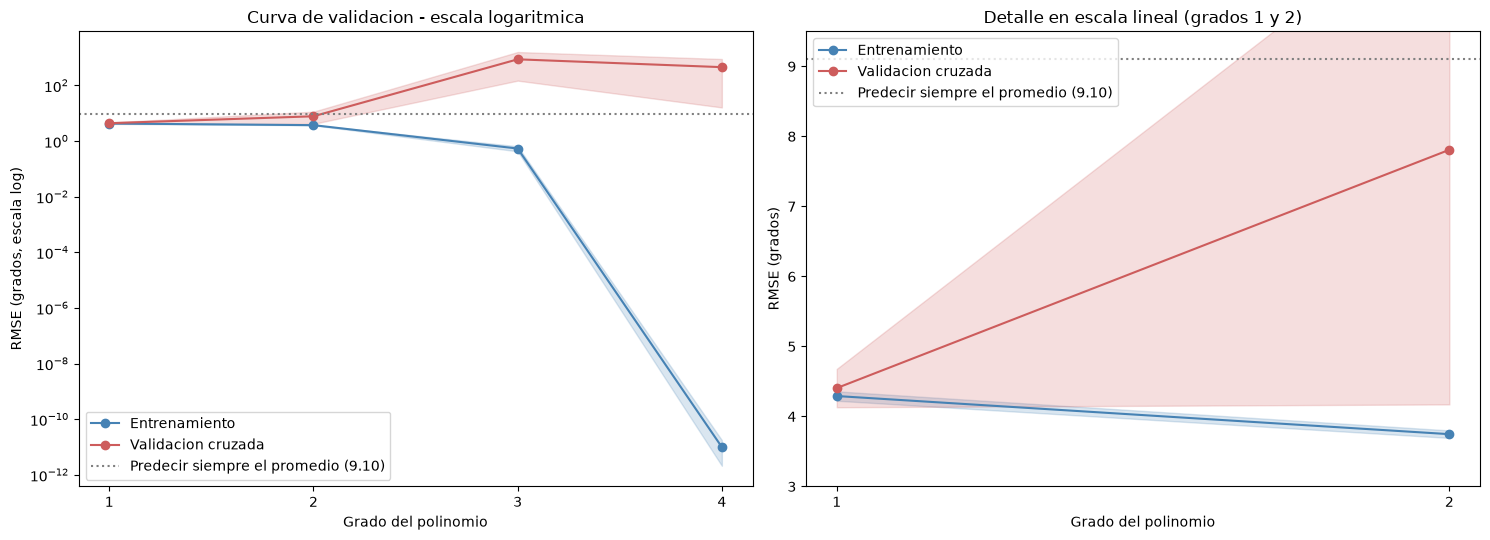

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# --- Grafico 1: los cuatro grados, escala logaritmica ---
ax = axes[0]
ax.plot(grados, train_media, 'o-', color='steelblue', label='Entrenamiento')
ax.fill_between(grados, train_media - train_desv, train_media + train_desv,
                alpha=0.2, color='steelblue')
ax.plot(grados, val_media, 'o-', color='indianred', label='Validacion cruzada')
ax.fill_between(grados, val_media - val_desv, val_media + val_desv,
                alpha=0.2, color='indianred')
ax.axhline(y_train.std(), color='gray', linestyle=':', linewidth=1.5,
           label=f'Predecir siempre el promedio ({y_train.std():.2f})')
ax.set_yscale('log')
ax.set_xticks(grados)
ax.set_title('Curva de validacion - escala logaritmica')
ax.set_xlabel('Grado del polinomio')
ax.set_ylabel('RMSE (grados, escala log)')
ax.legend()

# --- Grafico 2: solo grados 1 y 2, escala lineal ---
ax = axes[1]
n = 2
ax.plot(grados[:n], train_media[:n], 'o-', color='steelblue', label='Entrenamiento')
ax.fill_between(grados[:n], (train_media - train_desv)[:n], (train_media + train_desv)[:n],
                alpha=0.2, color='steelblue')
ax.plot(grados[:n], val_media[:n], 'o-', color='indianred', label='Validacion cruzada')
ax.fill_between(grados[:n], (val_media - val_desv)[:n], (val_media + val_desv)[:n],
                alpha=0.2, color='indianred')
ax.axhline(y_train.std(), color='gray', linestyle=':', linewidth=1.5,
           label=f'Predecir siempre el promedio ({y_train.std():.2f})')
ax.set_ylim(3, 9.5)
ax.set_xticks(grados[:n])
ax.set_title('Detalle en escala lineal (grados 1 y 2)')
ax.set_xlabel('Grado del polinomio')
ax.set_ylabel('RMSE (grados)')
ax.legend()

plt.tight_layout()
plt.show()

## 2.2 La brecha entre las dos curvas

La distancia vertical entre las dos curvas es la medida directa del sobreajuste: cuánto
peor se comporta el modelo con datos que no vio frente a los que sí usó para entrenar.
La graficamos aparte porque es el indicador que define en qué grado empieza el
problema.

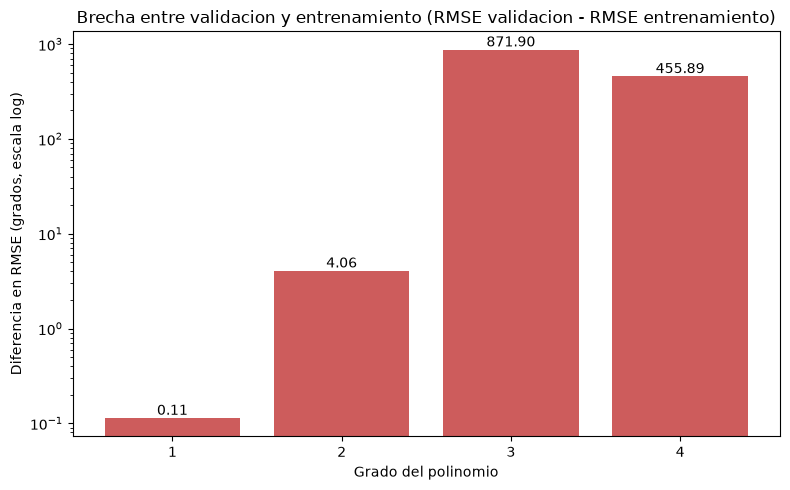

In [47]:
plt.figure(figsize=(8, 5))
plt.bar([str(g) for g in grados], curva['Brecha'], color='indianred')
plt.yscale('log')
plt.title('Brecha entre validacion y entrenamiento (RMSE validacion - RMSE entrenamiento)')
plt.xlabel('Grado del polinomio')
plt.ylabel('Diferencia en RMSE (grados, escala log)')
for i, v in enumerate(curva['Brecha']):
    plt.text(i, v, f'{v:.2f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

## 2.3 Interpretación de las curvas

Las curvas se abren en tijera: el error de entrenamiento baja siempre (4,29 → 3,75 → 0,54 → casi cero) mientras el de validación sube (4,41 → 7,81 → 872,44 → 455,89). El sobreajuste arranca en el grado 2, donde la brecha pasa de 0,11 a 4,06 grados y la curva de validación casi toca la línea del 9,10, que es el error de predecir siempre el
promedio. La banda de variabilidad hace lo mismo: de 0,27 grados de desviación entre pliegues a más de 3, y a cientos en los grados 3 y 4.

Esto es el sesgo-varianza visto en clase, pero sin la U típica: la curva de validación sube desde el primer paso, así que el grado 1 ya estaba en el óptimo y no había sesgo que corregir con más complejidad. Todo lo que se agrega después es varianza. Entonces aquí la complejidad no se controla bajando el grado, que ya está en su mínimo, sino penalizando el tamaño de los coeficientes, que es lo que hacen Ridge y Lasso.

# Actividad 3 - Modelos de regresión regularizada

La actividad anterior nos dejó una conclusión incómoda: el modelo más simple que
probamos es el que mejor generaliza, y subir el grado del polinomio solo empeora las
cosas. Eso no quiere decir que el modelo lineal esté libre de problemas. En el
Laboratorio 1, al verificar los supuestos, encontramos colinealidad alta entre varias
variables, sobre todo dentro de las familias de presión, viento y ráfaga, donde el
mínimo, la media y el máximo del mismo día están muy correlacionados por construcción.
La colinealidad no daña la predicción pero sí vuelve los coeficientes inestables.

La regularización es otra forma de controlar la complejidad, distinta a bajar el grado.
En vez de quitarle variables al modelo, le agrega a la función de costo un castigo por
el tamaño de los coeficientes, de manera que el modelo solo "paga" por un coeficiente
grande si de verdad le sirve para reducir el error. Los coeficientes quedan más
pequeños y más estables.

Las dos variantes que vimos en clase se diferencian en la forma de ese castigo:

| | Ridge (L2) | Lasso (L1) |
|---|---|---|
| Penalización | Suma de coeficientes al cuadrado | Suma de valores absolutos |
| Efecto sobre los pesos | Los encoge pero nunca llegan a cero | Puede llevarlos exactamente a cero |
| Con variables correlacionadas | Reparte el efecto entre ellas | Tiende a conservar solo una |
| Para qué sirve | Estabilizar cuando hay colinealidad | Selección automática de variables |

En ambos casos el hiperparámetro `alpha` controla qué tan fuerte es la penalización. Con
alpha cercano a cero el modelo se parece a la regresión lineal normal, y con alpha muy
grande todos los coeficientes se aplastan hacia cero y el modelo termina subajustado.
Ese valor no se aprende de los datos, hay que buscarlo, y eso es lo que hacemos con
GridSearchCV.

## 3.1 Modelo Ridge (regularización L2)

El pipeline es el mismo del modelo de referencia, cambiando `LinearRegression()` por
`Ridge()`. El preprocesamiento no cambia: imputación por mediana y escalado para las
numéricas, imputación por moda y One-Hot para las categóricas.

Para el espacio de búsqueda de alpha usamos una escala logarítmica en vez de valores
espaciados de forma uniforme. La razón es que el efecto de alpha no es lineal: la
diferencia entre 0,01 y 0,1 cambia el modelo mucho más que la diferencia entre 100 y
100,09. Recorriendo órdenes de magnitud se cubre un rango mucho más amplio con la misma
cantidad de valores. La práctica 6 usa valores cercanos entre sí ([10, 20, 30]), pero su
primer ejercicio propone precisamente explorar alpha en escala logarítmica, que es lo
que hacemos aquí.

In [48]:
pipeline_ridge = Pipeline(steps=[
    ("preprocesamiento", ColumnTransformer(transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                          ("scaler", StandardScaler())]), variables_numericas),
        ("cat", categorical_transformer, variables_categoricas),
    ])),
    ("modelo", Ridge()),
])

param_grid_ridge = {
    "modelo__alpha": [0.01, 0.1, 1, 10, 100, 1000],
    "preprocesamiento__num__scaler": [StandardScaler(), MinMaxScaler(), RobustScaler()],
}

grid_ridge = GridSearchCV(
    estimator=pipeline_ridge,
    param_grid=param_grid_ridge,
    cv=kfold,
    scoring=metricas_cv,
    refit='RMSE',
    return_train_score=True,
    n_jobs=-1
)

grid_ridge.fit(X_train, y_train)

print("Mejores hiperparametros Ridge:", grid_ridge.best_params_)
print(f"Mejor RMSE en validacion cruzada: {-grid_ridge.best_score_:.4f}")
print(f"Desviacion estandar del RMSE    : "
      f"{grid_ridge.cv_results_['std_test_RMSE'][grid_ridge.best_index_]:.4f}")

best_ridge = grid_ridge.best_estimator_
metricas_ridge = reporte("ACTIVIDAD 3 — Mejor modelo Ridge",
                         best_ridge, X_train, y_train, X_test, y_test)

Mejores hiperparametros Ridge: {'modelo__alpha': 1, 'preprocesamiento__num__scaler': MinMaxScaler()}
Mejor RMSE en validacion cruzada: 4.4027
Desviacion estandar del RMSE    : 0.2778
=== ACTIVIDAD 3 — Mejor modelo Ridge ===
                 RMSE     MAE      R2
Entrenamiento  4.3081  3.4307  0.7758
Prueba         4.1740  3.3309  0.7664


In [49]:
res_ridge = pd.DataFrame(grid_ridge.cv_results_)
tabla_ridge = pd.DataFrame({
    'alpha': res_ridge['param_modelo__alpha'],
    'Escalador': [type(s).__name__ for s in res_ridge['param_preprocesamiento__num__scaler']],
    'RMSE_val': -res_ridge['mean_test_RMSE'],
    'RMSE_val_std': res_ridge['std_test_RMSE'],
    'R2_val': res_ridge['mean_test_R2'],
}).sort_values(['Escalador', 'alpha'])

print("=== Ridge: desempeno de todas las combinaciones ===")
print(tabla_ridge.round(4).to_string(index=False))

=== Ridge: desempeno de todas las combinaciones ===
  alpha      Escalador  RMSE_val  RMSE_val_std  R2_val
   0.01   MinMaxScaler    4.4050        0.2741  0.7654
   0.10   MinMaxScaler    4.4039        0.2755  0.7655
   1.00   MinMaxScaler    4.4027        0.2778  0.7656
  10.00   MinMaxScaler    4.4613        0.2943  0.7593
 100.00   MinMaxScaler    5.4474        0.3273  0.6413
1000.00   MinMaxScaler    8.0966        0.3083  0.2073
   0.01   RobustScaler    4.4053        0.2737  0.7653
   0.10   RobustScaler    4.4051        0.2740  0.7653
   1.00   RobustScaler    4.4045        0.2767  0.7654
  10.00   RobustScaler    4.4499        0.2869  0.7606
 100.00   RobustScaler    5.3442        0.2693  0.6547
1000.00   RobustScaler    6.9458        0.2502  0.4164
   0.01 StandardScaler    4.4053        0.2737  0.7653
   0.10 StandardScaler    4.4052        0.2740  0.7653
   1.00 StandardScaler    4.4046        0.2766  0.7654
  10.00 StandardScaler    4.4508        0.2875  0.7605
 100.00 Stand

## 3.2 Modelo Lasso (regularización L1)

El pipeline es idéntico al de Ridge cambiando solo el modelo. Le pasamos
`max_iter=10000` porque Lasso no tiene solución cerrada como Ridge y se resuelve de
forma iterativa; con el valor por defecto scikit-learn suele advertir que el algoritmo
no alcanzó a converger.

El rango de alpha es distinto al de Ridge y esto no es arbitrario. Las dos penalizaciones
no están en la misma escala: Ridge suma coeficientes al cuadrado y Lasso suma valores
absolutos, así que un mismo alpha produce castigos de magnitud muy distinta. Por eso los
rangos se exploran por separado, tal como hace la práctica 6, que usa [10, 20, 30] para
Ridge y [100, 200, 300] para Lasso.

In [50]:
pipeline_lasso = Pipeline(steps=[
    ("preprocesamiento", ColumnTransformer(transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                          ("scaler", StandardScaler())]), variables_numericas),
        ("cat", categorical_transformer, variables_categoricas),
    ])),
    ("modelo", Lasso(max_iter=10000)),
])

param_grid_lasso = {
    "modelo__alpha": [0.001, 0.01, 0.05, 0.1, 0.5, 1, 5],
    "preprocesamiento__num__scaler": [StandardScaler(), MinMaxScaler(), RobustScaler()],
}

grid_lasso = GridSearchCV(
    estimator=pipeline_lasso,
    param_grid=param_grid_lasso,
    cv=kfold,
    scoring=metricas_cv,
    refit='RMSE',
    return_train_score=True,
    n_jobs=-1
)

grid_lasso.fit(X_train, y_train)

print("Mejores hiperparametros Lasso:", grid_lasso.best_params_)
print(f"Mejor RMSE en validacion cruzada: {-grid_lasso.best_score_:.4f}")
print(f"Desviacion estandar del RMSE    : "
      f"{grid_lasso.cv_results_['std_test_RMSE'][grid_lasso.best_index_]:.4f}")

best_lasso = grid_lasso.best_estimator_
metricas_lasso = reporte("ACTIVIDAD 3 — Mejor modelo Lasso",
                         best_lasso, X_train, y_train, X_test, y_test)

Mejores hiperparametros Lasso: {'modelo__alpha': 0.01, 'preprocesamiento__num__scaler': MinMaxScaler()}
Mejor RMSE en validacion cruzada: 4.3999
Desviacion estandar del RMSE    : 0.2853
=== ACTIVIDAD 3 — Mejor modelo Lasso ===
                 RMSE     MAE      R2
Entrenamiento  4.3225  3.4400  0.7743
Prueba         4.1811  3.3321  0.7656


In [51]:
res_lasso = pd.DataFrame(grid_lasso.cv_results_)
tabla_lasso = pd.DataFrame({
    'alpha': res_lasso['param_modelo__alpha'],
    'Escalador': [type(s).__name__ for s in res_lasso['param_preprocesamiento__num__scaler']],
    'RMSE_val': -res_lasso['mean_test_RMSE'],
    'RMSE_val_std': res_lasso['std_test_RMSE'],
    'R2_val': res_lasso['mean_test_R2'],
}).sort_values(['Escalador', 'alpha'])

print("=== Lasso: desempeno de todas las combinaciones ===")
print(tabla_lasso.round(4).to_string(index=False))

=== Lasso: desempeno de todas las combinaciones ===
 alpha      Escalador  RMSE_val  RMSE_val_std  R2_val
 0.001   MinMaxScaler    4.4014        0.2765  0.7657
 0.010   MinMaxScaler    4.3999        0.2853  0.7659
 0.050   MinMaxScaler    4.5392        0.2801  0.7508
 0.100   MinMaxScaler    4.7465        0.2787  0.7275
 0.500   MinMaxScaler    6.7715        0.3127  0.4456
 1.000   MinMaxScaler    8.7131        0.3295  0.0819
 5.000   MinMaxScaler    9.0949        0.3007 -0.0006
 0.001   RobustScaler    4.4043        0.2753  0.7654
 0.010   RobustScaler    4.4058        0.2788  0.7653
 0.050   RobustScaler    4.4620        0.2703  0.7593
 0.100   RobustScaler    4.6097        0.2660  0.7431
 0.500   RobustScaler    6.7614        0.2692  0.4466
 1.000   RobustScaler    7.2980        0.2518  0.3554
 5.000   RobustScaler    9.0949        0.3007 -0.0006
 0.001 StandardScaler    4.4044        0.2752  0.7654
 0.010 StandardScaler    4.4067        0.2789  0.7652
 0.050 StandardScaler    4.462

## 3.3 Comparación de los tres modelos y efecto sobre los coeficientes

Ya tenemos los tres modelos entrenados, así que los juntamos para ver cuál rinde mejor y
qué le hizo la penalización a los coeficientes. Como los tres pipelines producen las
mismas 39 columnas, los coeficientes se pueden comparar uno a uno entre modelos.

In [52]:
comparacion_a3 = pd.DataFrame({
    'Sin regularizacion': metricas_lineal.loc['Prueba'],
    'Ridge (L2)': metricas_ridge.loc['Prueba'],
    'Lasso (L1)': metricas_lasso.loc['Prueba'],
}).T
comparacion_a3['RMSE_val_cv'] = [-grid_polinomial.best_score_,
                                 -grid_ridge.best_score_,
                                 -grid_lasso.best_score_]
comparacion_a3['Desv_val_cv'] = [
    grid_polinomial.cv_results_['std_test_RMSE'][grid_polinomial.best_index_],
    grid_ridge.cv_results_['std_test_RMSE'][grid_ridge.best_index_],
    grid_lasso.cv_results_['std_test_RMSE'][grid_lasso.best_index_],
]

print("=== Comparacion de los tres modelos ===")
print(comparacion_a3.round(4).to_string())

=== Comparacion de los tres modelos ===
                      RMSE     MAE      R2  RMSE_val_cv  Desv_val_cv
Sin regularizacion  4.1761  3.3364  0.7661       4.4053       0.2737
Ridge (L2)          4.1740  3.3309  0.7664       4.4027       0.2778
Lasso (L1)          4.1811  3.3321  0.7656       4.3999       0.2853


In [53]:
def extraer_coef(modelo_pipeline):
    nombres = modelo_pipeline.named_steps['preprocesamiento'].get_feature_names_out()
    nombres = [n.split('__')[-1] for n in nombres]
    return pd.Series(modelo_pipeline.named_steps['modelo'].coef_, index=nombres)

coef_comparacion = pd.DataFrame({
    'Sin regularizacion': extraer_coef(modelo_lineal),
    'Ridge': extraer_coef(best_ridge),
    'Lasso': extraer_coef(best_lasso),
})

print("=== Magnitud de los coeficientes ===")
resumen_coef = pd.DataFrame({
    'Suma de |coeficientes|': coef_comparacion.abs().sum(),
    'Coeficiente mas grande (abs)': coef_comparacion.abs().max(),
    'Coeficientes exactamente en cero': (coef_comparacion == 0).sum(),
    'Variables activas': (coef_comparacion != 0).sum(),
})
print(resumen_coef.round(4).to_string())
print()
print(coef_comparacion.round(4).to_string())

=== Magnitud de los coeficientes ===
                    Suma de |coeficientes|  Coeficiente mas grande (abs)  Coeficientes exactamente en cero  Variables activas
Sin regularizacion                 88.9780                       10.2159                                 0                 39
Ridge                             124.8474                       11.6741                                 0                 39
Lasso                             109.6934                       11.4035                                10                 29

                  Sin regularizacion    Ridge    Lasso
presion_media                 1.2939   4.4500   3.8001
presion_min                  -0.5779   0.3632   0.0000
presion_max                  -0.2248  -0.6586   0.0000
presion_desv                 -0.3822  -2.6310  -2.0634
humedad_media                -0.4869  -2.5416  -2.8861
humedad_min                   0.1461   0.2189  -0.0000
humedad_max                  -0.2069  -1.3484  -0.5411
humedad_desv      

In [54]:
anuladas = coef_comparacion[coef_comparacion['Lasso'] == 0].index.tolist()

print(f"Variables llevadas a cero por Lasso: {len(anuladas)} de {len(coef_comparacion)}")
print()
for v in anuladas:
    print(f"  {v:25s} (sin regularizacion: {coef_comparacion.loc[v, 'Sin regularizacion']:8.4f} | "
          f"Ridge: {coef_comparacion.loc[v, 'Ridge']:8.4f})")

Variables llevadas a cero por Lasso: 10 de 39

  presion_min               (sin regularizacion:  -0.5779 | Ridge:   0.3632)
  presion_max               (sin regularizacion:  -0.2248 | Ridge:  -0.6586)
  humedad_min               (sin regularizacion:   0.1461 | Ridge:   0.2189)
  viento_media              (sin regularizacion:   0.0079 | Ridge:  -0.2220)
  viento_min                (sin regularizacion:  -0.2059 | Ridge:  -3.1150)
  viento_desv               (sin regularizacion:  -0.0608 | Ridge:  -1.0419)
  rafaga_media              (sin regularizacion:   0.0279 | Ridge:  -0.1170)
  rafaga_max                (sin regularizacion:  -0.1701 | Ridge:  -1.3074)
  rafaga_desv               (sin regularizacion:   0.0544 | Ridge:   0.7960)
  viento_este               (sin regularizacion:  -0.0369 | Ridge:  -1.0315)


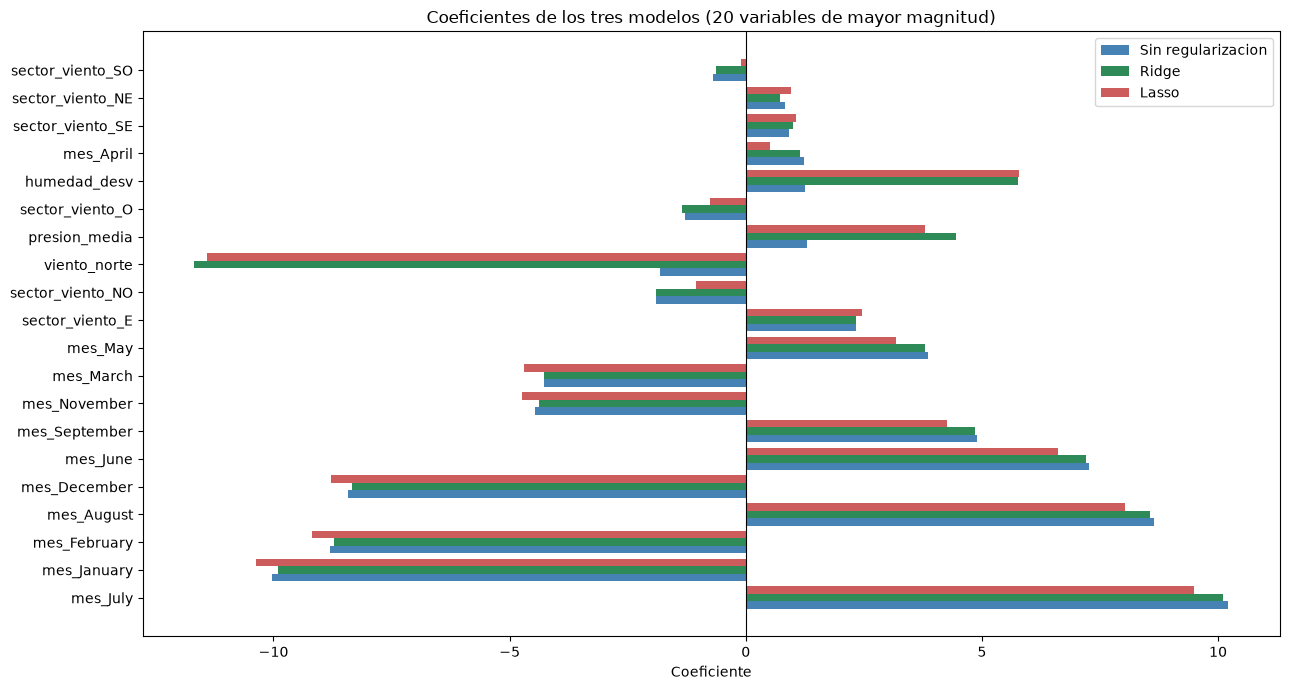

In [55]:
orden = coef_comparacion['Sin regularizacion'].abs().sort_values(ascending=False).index[:20]
comp_top = coef_comparacion.loc[orden]

x = np.arange(len(comp_top))
ancho = 0.27

plt.figure(figsize=(13, 7))
plt.barh(x - ancho, comp_top['Sin regularizacion'], ancho, label='Sin regularizacion', color='steelblue')
plt.barh(x, comp_top['Ridge'], ancho, label='Ridge', color='seagreen')
plt.barh(x + ancho, comp_top['Lasso'], ancho, label='Lasso', color='indianred')
plt.yticks(x, comp_top.index)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coeficiente')
plt.title('Coeficientes de los tres modelos (20 variables de mayor magnitud)')
plt.legend()
plt.tight_layout()
plt.show()

## 3.4 Análisis

Los tres modelos rinden prácticamente igual. En prueba Ridge da 4,1740, el modelo sin
regularizar 4,1761 y Lasso 4,1811, diferencias de centésimas de grado. En validación
cruzada el orden se invierte (4,3999 / 4,4027 / 4,4053) pero las diferencias son menores
que la desviación entre pliegues, que ronda 0,28 en los tres, así que no se puede decir
que uno sea mejor.

Tiene sentido: la regularización sirve para controlar sobreajuste y este modelo no lo
tiene, su error en prueba es incluso menor que en entrenamiento. Por eso la búsqueda
eligió alphas muy bajos (1 en Ridge, 0,01 en Lasso) y al subirlos el error empeora
siempre, hasta 8,10 y 9,09 en los extremos, donde el modelo ya se subajusta.

| | Suma de \|coef\| | Variables en cero | Variables activas |
|---|---|---|---|
| Sin regularización | 88,98 | 0 | 39 |
| Ridge | 124,85 | 0 | 39 |
| Lasso | 109,69 | 10 | 29 |

Que Ridge tenga coeficientes más grandes que el modelo sin penalizar no es un error de
la penalización sino de escala: la búsqueda le asignó `MinMaxScaler`, que deja las
variables en [0,1], mientras el de referencia usa `StandardScaler`. La comparación válida
es Ridge contra Lasso, que comparten escalador: ahí Lasso baja la suma a 109,69 y deja 10
coeficientes en cero, mientras Ridge no anula ninguno. Donde sí se ve el efecto
estabilizador de Ridge es en las familias correlacionadas, por ejemplo `viento_min` pasa
de −0,21 a −3,12 y `rafaga_min` de −0,51 a −5,11: Ridge reparte el efecto entre variables
que en el Laboratorio 1 ya habíamos detectado con VIF alto.

Lasso anula `presion_min`, `presion_max`, `humedad_min`, `viento_media`, `viento_min`,
`viento_desv`, `rafaga_media`, `rafaga_max`, `rafaga_desv` y `viento_este`. Todas son
numéricas y redundantes dentro de su familia: de las cuatro de ráfaga sobrevive solo
`rafaga_min`, de las de viento solo `viento_max`. No anula ninguna dummy de `mes` ni de
`sector_viento`, y deja `viento_norte` con el coeficiente más grande del modelo (−11,40).
Es la misma conclusión del Laboratorio 1, pero a la que llega solo.

Para interpretabilidad esto es una ventaja: 29 variables en vez de 39 con el mismo
desempeño. Pero hay que tener cuidado al leerlo, porque las variables anuladas no son
irrelevantes para la temperatura, son redundantes dadas las que quedaron. Cuando dos
están muy correlacionadas Lasso conserva una y bota la otra, y cuál sobreviva puede
depender de detalles de los datos.

# Actividad 4 - Modelo de regresión polinomial regularizado

En las Actividades 1 y 2 vimos que subir el grado del polinomio sin más solo empeora la
generalización: sin regularizar, el RMSE de validación pasa de 4,41 en grado 1 a 7,81 en
grado 2 y hasta 872 en grado 3 (con StandardScaler; entre 699 y 872 según el escalador),
mientras el error de entrenamiento baja hasta 0,54. Es sobreajuste clásico: con 1.559
coeficientes y apenas 1,15 filas por parámetro en grado 3, el modelo memoriza en vez de
generalizar. En la Actividad 3 vimos, por otro lado, que la regularización aplicada
sobre el modelo lineal (grado 1) casi no cambia nada, porque ese modelo no tenía
sobreajuste que corregir.

Esta actividad junta las dos cosas: se expande el espacio de variables con
`PolynomialFeatures` y, sobre ese espacio ya expandido, se aplica Ridge o Lasso. La
pregunta que responde es si una penalización lo bastante fuerte permite usar un grado
más alto que en la Actividad 1 sin pagar el costo en varianza que vimos ahí, en vez de
quedarse con el grado 1 como única opción viable.

Se busca conjuntamente sobre tres hiperparámetros: grado, alpha y escalador. Los rangos
de alpha se amplían respecto a la Actividad 3 (hasta 10.000 en Ridge y hasta 10 en
Lasso), porque domar un modelo que sin penalizar llega a un RMSE de 872 probablemente
necesita un castigo bastante más fuerte que el que le bastó al modelo lineal.

## 4.1 Modelo polinomial + Ridge

El pipeline combina la rama numérica de la Actividad 1 (imputar → escalar →
`PolynomialFeatures`) con `Ridge()` como modelo final, igual que en la Actividad 3. El
`param_grid` explora los tres hiperparámetros a la vez: grado en {1, 2, 3}, alpha en
escala logarítmica desde 0,01 hasta 10.000, y los tres escaladores. Son 7 × 3 × 3 = 63
combinaciones, 315 ajustes contando los 5 pliegues.

In [56]:
pipeline_polinomial_ridge = Pipeline(steps=[
    ("preprocesamiento", ColumnTransformer(transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                          ("scaler", StandardScaler()),
                          ("polynomial", PolynomialFeatures(degree=2, include_bias=False))]),
         variables_numericas),
        ("cat", categorical_transformer, variables_categoricas),
    ])),
    ("modelo", Ridge()),
])

param_grid_polinomial_ridge = {
    "preprocesamiento__num__polynomial__degree": [1, 2, 3],
    "modelo__alpha": [0.01, 0.1, 1, 10, 100, 1000, 10000],
    "preprocesamiento__num__scaler": [StandardScaler(), MinMaxScaler(), RobustScaler()],
}

grid_polinomial_ridge = GridSearchCV(
    estimator=pipeline_polinomial_ridge,
    param_grid=param_grid_polinomial_ridge,
    cv=kfold,
    scoring=metricas_cv,
    refit='RMSE',
    return_train_score=True,
    n_jobs=-1
)

print(f"Combinaciones a evaluar: {3 * 7 * 3}")
print(f"Modelos que se entrenan: {3 * 7 * 3 * kfold.get_n_splits()}")

Combinaciones a evaluar: 63
Modelos que se entrenan: 315


In [57]:
%%time
grid_polinomial_ridge.fit(X_train, y_train)

print("Mejores hiperparametros Ridge + polinomial:", grid_polinomial_ridge.best_params_)
print(f"Mejor RMSE en validacion cruzada: {-grid_polinomial_ridge.best_score_:.4f}")
print(f"Desviacion estandar del RMSE    : "
      f"{grid_polinomial_ridge.cv_results_['std_test_RMSE'][grid_polinomial_ridge.best_index_]:.4f}")

best_polinomial_ridge = grid_polinomial_ridge.best_estimator_
metricas_polinomial_ridge = reporte("ACTIVIDAD 4 — Mejor modelo Ridge + polinomial",
                                    best_polinomial_ridge, X_train, y_train, X_test, y_test)

Mejores hiperparametros Ridge + polinomial: {'modelo__alpha': 1, 'preprocesamiento__num__polynomial__degree': 3, 'preprocesamiento__num__scaler': MinMaxScaler()}
Mejor RMSE en validacion cruzada: 4.2203
Desviacion estandar del RMSE    : 0.2369
=== ACTIVIDAD 4 — Mejor modelo Ridge + polinomial ===
                 RMSE     MAE      R2
Entrenamiento  3.9338  3.1429  0.8131
Prueba         3.9898  3.1636  0.7865
CPU times: total: 2.3 s
Wall time: 8.22 s


## 4.2 Resultados por grado (Ridge)

`cv_results_` tiene las 63 combinaciones completas, pero para ver el efecto que
buscamos alcanza con quedarnos, para cada grado, con la mejor combinación de alpha y
escalador. Si Ridge logra controlar el sobreajuste que vimos en la Actividad 1, se
debería ver que para los grados 2 y 3 la brecha entre validación y entrenamiento baja
mucho respecto a los 4,06 y 871,90 grados que dieron sin regularizar.

In [58]:
res_ridge_poli = pd.DataFrame(grid_polinomial_ridge.cv_results_)
res_ridge_poli['Grado'] = res_ridge_poli['param_preprocesamiento__num__polynomial__degree']
res_ridge_poli['alpha'] = res_ridge_poli['param_modelo__alpha']
res_ridge_poli['Escalador'] = [type(s).__name__ for s in res_ridge_poli['param_preprocesamiento__num__scaler']]
res_ridge_poli['RMSE_val'] = -res_ridge_poli['mean_test_RMSE']
res_ridge_poli['RMSE_val_std'] = res_ridge_poli['std_test_RMSE']
res_ridge_poli['RMSE_train'] = -res_ridge_poli['mean_train_RMSE']
res_ridge_poli['Brecha'] = res_ridge_poli['RMSE_val'] - res_ridge_poli['RMSE_train']

mejor_por_grado_ridge = res_ridge_poli.loc[
    res_ridge_poli.groupby('Grado')['RMSE_val'].idxmin(),
    ['Grado', 'alpha', 'Escalador', 'RMSE_val', 'RMSE_val_std', 'RMSE_train', 'Brecha']
].sort_values('Grado')

print("=== Ridge + polinomial: mejor alpha/escalador encontrado para cada grado ===")
print(mejor_por_grado_ridge.round(4).to_string(index=False))

=== Ridge + polinomial: mejor alpha/escalador encontrado para cada grado ===
 Grado  alpha    Escalador  RMSE_val  RMSE_val_std  RMSE_train  Brecha
     1    1.0 MinMaxScaler    4.4027        0.2778      4.2967  0.1060
     2    1.0 MinMaxScaler    4.2434        0.2308      4.0547  0.1887
     3    1.0 MinMaxScaler    4.2203        0.2369      3.9061  0.3143


## 4.3 Modelo polinomial + Lasso

Mismo pipeline cambiando el modelo final por `Lasso(max_iter=10000)`, igual que en la
Actividad 3. El rango de alpha es distinto al de Ridge por la misma razón de la
Actividad 3: las dos penalizaciones no están en la misma escala. Aquí se usa de 0,001 a
10, sin llegar tan alto como Ridge porque Lasso ya lleva coeficientes a cero con valores
mucho menores. Son 3 × 6 × 3 = 54 combinaciones, 270 ajustes.

In [59]:
pipeline_polinomial_lasso = Pipeline(steps=[
    ("preprocesamiento", ColumnTransformer(transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                          ("scaler", StandardScaler()),
                          ("polynomial", PolynomialFeatures(degree=2, include_bias=False))]),
         variables_numericas),
        ("cat", categorical_transformer, variables_categoricas),
    ])),
    ("modelo", Lasso(max_iter=10000)),
])

param_grid_polinomial_lasso = {
    "preprocesamiento__num__polynomial__degree": [1, 2, 3],
    "modelo__alpha": [0.001, 0.01, 0.1, 1, 5, 10],
    "preprocesamiento__num__scaler": [StandardScaler(), MinMaxScaler(), RobustScaler()],
}

grid_polinomial_lasso = GridSearchCV(
    estimator=pipeline_polinomial_lasso,
    param_grid=param_grid_polinomial_lasso,
    cv=kfold,
    scoring=metricas_cv,
    refit='RMSE',
    return_train_score=True,
    n_jobs=-1
)

print(f"Combinaciones a evaluar: {3 * 6 * 3}")
print(f"Modelos que se entrenan: {3 * 6 * 3 * kfold.get_n_splits()}")

Combinaciones a evaluar: 54
Modelos que se entrenan: 270


In [60]:
%%time
grid_polinomial_lasso.fit(X_train, y_train)

print("Mejores hiperparametros Lasso + polinomial:", grid_polinomial_lasso.best_params_)
print(f"Mejor RMSE en validacion cruzada: {-grid_polinomial_lasso.best_score_:.4f}")
print(f"Desviacion estandar del RMSE    : "
      f"{grid_polinomial_lasso.cv_results_['std_test_RMSE'][grid_polinomial_lasso.best_index_]:.4f}")

best_polinomial_lasso = grid_polinomial_lasso.best_estimator_
metricas_polinomial_lasso = reporte("ACTIVIDAD 4 — Mejor modelo Lasso + polinomial",
                                    best_polinomial_lasso, X_train, y_train, X_test, y_test)

Mejores hiperparametros Lasso + polinomial: {'modelo__alpha': 0.001, 'preprocesamiento__num__polynomial__degree': 3, 'preprocesamiento__num__scaler': MinMaxScaler()}
Mejor RMSE en validacion cruzada: 4.2309
Desviacion estandar del RMSE    : 0.2013
=== ACTIVIDAD 4 — Mejor modelo Lasso + polinomial ===
                 RMSE     MAE      R2
Entrenamiento  3.9314  3.1473  0.8133
Prueba         3.9864  3.1719  0.7869
CPU times: total: 21.7 s
Wall time: 4min 38s


## 4.4 Resultados por grado (Lasso)

Misma lógica que en 4.2: para cada grado, la mejor combinación de alpha y escalador
encontrada por la búsqueda.

In [61]:
res_lasso_poli = pd.DataFrame(grid_polinomial_lasso.cv_results_)
res_lasso_poli['Grado'] = res_lasso_poli['param_preprocesamiento__num__polynomial__degree']
res_lasso_poli['alpha'] = res_lasso_poli['param_modelo__alpha']
res_lasso_poli['Escalador'] = [type(s).__name__ for s in res_lasso_poli['param_preprocesamiento__num__scaler']]
res_lasso_poli['RMSE_val'] = -res_lasso_poli['mean_test_RMSE']
res_lasso_poli['RMSE_val_std'] = res_lasso_poli['std_test_RMSE']
res_lasso_poli['RMSE_train'] = -res_lasso_poli['mean_train_RMSE']
res_lasso_poli['Brecha'] = res_lasso_poli['RMSE_val'] - res_lasso_poli['RMSE_train']

mejor_por_grado_lasso = res_lasso_poli.loc[
    res_lasso_poli.groupby('Grado')['RMSE_val'].idxmin(),
    ['Grado', 'alpha', 'Escalador', 'RMSE_val', 'RMSE_val_std', 'RMSE_train', 'Brecha']
].sort_values('Grado')

print("=== Lasso + polinomial: mejor alpha/escalador encontrado para cada grado ===")
print(mejor_por_grado_lasso.round(4).to_string(index=False))

=== Lasso + polinomial: mejor alpha/escalador encontrado para cada grado ===
 Grado  alpha    Escalador  RMSE_val  RMSE_val_std  RMSE_train  Brecha
     1  0.010 MinMaxScaler    4.3999        0.2853      4.3104  0.0896
     2  0.001 MinMaxScaler    4.2451        0.2305      3.9867  0.2584
     3  0.001 MinMaxScaler    4.2309        0.2013      3.8700  0.3609


## 4.5 Comparación de los cinco modelos y efecto sobre el sobreajuste

Juntamos el mejor modelo de cada enfoque visto hasta ahora: polinomial sin regularizar
(Actividad 1), Ridge y Lasso sin expansión polinomial (Actividad 3), y Ridge y Lasso
combinados con la expansión polinomial (esta actividad). Además del desempeño en prueba
y en validación cruzada, se incluye el grado que terminó escogiendo cada búsqueda, que
es lo que permite responder si la regularización habilitó usar un grado mayor a 1.

In [62]:
comparacion_a4 = pd.DataFrame({
    'Polinomial sin regularizar (Act.1)': metricas_polinomial.loc['Prueba'],
    'Ridge sin polinomio (Act.3)': metricas_ridge.loc['Prueba'],
    'Lasso sin polinomio (Act.3)': metricas_lasso.loc['Prueba'],
    'Ridge + polinomial (Act.4)': metricas_polinomial_ridge.loc['Prueba'],
    'Lasso + polinomial (Act.4)': metricas_polinomial_lasso.loc['Prueba'],
}).T

comparacion_a4['Grado_ganador'] = [
    grid_polinomial.best_params_['preprocesamiento__num__polynomial__degree'],
    1,
    1,
    grid_polinomial_ridge.best_params_['preprocesamiento__num__polynomial__degree'],
    grid_polinomial_lasso.best_params_['preprocesamiento__num__polynomial__degree'],
]
comparacion_a4['RMSE_val_cv'] = [
    -grid_polinomial.best_score_,
    -grid_ridge.best_score_,
    -grid_lasso.best_score_,
    -grid_polinomial_ridge.best_score_,
    -grid_polinomial_lasso.best_score_,
]
comparacion_a4['Desv_val_cv'] = [
    grid_polinomial.cv_results_['std_test_RMSE'][grid_polinomial.best_index_],
    grid_ridge.cv_results_['std_test_RMSE'][grid_ridge.best_index_],
    grid_lasso.cv_results_['std_test_RMSE'][grid_lasso.best_index_],
    grid_polinomial_ridge.cv_results_['std_test_RMSE'][grid_polinomial_ridge.best_index_],
    grid_polinomial_lasso.cv_results_['std_test_RMSE'][grid_polinomial_lasso.best_index_],
]

print("=== Comparacion de los cinco modelos ===")
print(comparacion_a4.round(4).to_string())

=== Comparacion de los cinco modelos ===
                                      RMSE     MAE      R2  Grado_ganador  RMSE_val_cv  Desv_val_cv
Polinomial sin regularizar (Act.1)  4.1761  3.3364  0.7661              1       4.4053       0.2737
Ridge sin polinomio (Act.3)         4.1740  3.3309  0.7664              1       4.4027       0.2778
Lasso sin polinomio (Act.3)         4.1811  3.3321  0.7656              1       4.3999       0.2853
Ridge + polinomial (Act.4)          3.9898  3.1636  0.7865              3       4.2203       0.2369
Lasso + polinomial (Act.4)          3.9864  3.1719  0.7869              3       4.2309       0.2013


## 4.6 Análisis

La pregunta que abrió la actividad era si una penalización suficientemente fuerte
permite aprovechar un grado más alto que el 1, controlando la varianza que en la
Actividad 1 hacía inservible el grado 3. La respuesta es sí, y de forma bastante clara:
en ambos modelos la búsqueda terminó escogiendo grado 3, no grado 1.

La brecha entre validación y entrenamiento en grado 3 pasa de 871,90 (sin regularizar,
Actividad 1) a 0,3143 con Ridge y 0,3609 con Lasso: se reduce por un factor de casi
2.770 en Ridge y 2.420 en Lasso. No es que la regularización haga desaparecer el
sobreajuste del grado 3 -- de hecho la brecha sigue creciendo con el grado incluso
regularizada (Ridge: 0,1060 → 0,1887 → 0,3143; Lasso: 0,0896 → 0,2584 → 0,3609), sino
que la mantiene en un rango donde la reducción de sesgo que trae la mayor complejidad
todavía gana. El RMSE de validación baja en los dos modelos a medida que sube el grado
(Ridge: 4,4027 → 4,2434 → 4,2203; Lasso: 4,3999 → 4,2451 → 4,2309), señal de que en
grado 3 el balance sesgo-varianza sigue siendo favorable, aunque probablemente no por
mucho más margen si el grid hubiera incluido un grado 4.

Sobre el desempeño en prueba, la tabla de los cinco modelos deja ver el salto real:

| Modelo | RMSE prueba | MAE prueba | R² prueba | Grado ganador | RMSE val. (CV) | Desv. CV |
|---|---|---|---|---|---|---|
| Polinomial sin regularizar (Act.1) | 4,1761 | 3,3364 | 0,7661 | 1 | 4,4053 | 0,2737 |
| Ridge sin polinomio (Act.3) | 4,1740 | 3,3309 | 0,7664 | 1 | 4,4027 | 0,2778 |
| Lasso sin polinomio (Act.3) | 4,1811 | 3,3321 | 0,7656 | 1 | 4,3999 | 0,2853 |
| Ridge + polinomial (Act.4) | 3,9898 | 3,1636 | 0,7865 | 3 | 4,2203 | 0,2369 |
| Lasso + polinomial (Act.4) | 3,9864 | 3,1719 | 0,7869 | 3 | 4,2309 | 0,2013 |

Frente a la referencia sin regularizar (RMSE 4,1761), Ridge+polinomial baja a 3,9898 y
Lasso+polinomial a 3,9864, una mejora de cerca de 0,19 °C (4,5%), y el R² sube a
alrededor de 0,787, unos 2 puntos porcentuales por encima del 0,7661 de referencia. Es
la primera vez en todo el laboratorio que subir la complejidad del modelo efectivamente
mejora el desempeño: en las Actividades 1 y 3 por separado, ni el polinomio solo ni la
regularización sola lo habían logrado.

Ridge y Lasso quedan prácticamente empatados. Lasso tiene un RMSE de prueba ligeramente
menor (3,9864 frente a 3,9898) y, sobre todo, una desviación estándar en validación
cruzada notablemente más baja (0,2013 frente a 0,2369): es el modelo más estable de los
cinco, más incluso que los de grado 1. Ridge gana por un margen mínimo en el RMSE
promedio de validación cruzada (4,2203 frente a 4,2309). La diferencia entre ambos es
demasiado pequeña frente a esas desviaciones como para preferir uno con confianza real;
al considerar formalmente el criterio de estabilidad en la Actividad 5, es probable que
Lasso tenga una ligera ventaja por su menor varianza entre pliegues.

Un detalle llamativo: en Ridge el mejor alpha se mantiene igual (1) en los tres grados,
pero en Lasso el alpha óptimo baja a medida que sube el grado (0,01 → 0,001 → 0,001).
Parece contraintuitivo, más variables deberían pedir más penalización, no menos,
pero tiene sentido con cómo actúa Lasso: al escalar con `MinMaxScaler`, todas las
variables (incluidas las potencias y productos que agrega el polinomio) quedan acotadas
en [0,1], y con cientos de columnas fuertemente correlacionadas entre sí, un alpha
pequeño ya alcanza para anular buena parte de ellas, porque compiten por el mismo
"presupuesto" de señal. Subir más el alpha en ese escenario empezaría a penalizar
también las variables que sí aportan.

Conclusión de la actividad: combinar polinomio con regularización sí mejora sobre
cualquiera de las dos técnicas por separado, y es la primera mejora real que se logra
sobre el modelo lineal de referencia en todo el laboratorio. Queda pendiente para la
Actividad 5 decidir formalmente cuál de los cinco modelos es el mejor considerando en
conjunto desempeño y estabilidad, no solo el promedio.

# Actividad 5 - Tabla comparativa de resultados

Hasta ahora cada actividad comparó sus propios modelos por separado. Esta actividad
junta los cinco en una sola tabla -- sin regularizar, Ridge, Lasso, Ridge+polinomial y
Lasso+polinomial -- y agrega dos cosas que no estaban juntas en ningún lado: los
hiperparámetros que ganó cada búsqueda, y un criterio de selección que no mire solo el
promedio del error.

La razón para no mirar solo el promedio es lo que ya vimos en la Actividad 1: dos
modelos pueden tener RMSE de validación parecido pero desviación estándar entre
pliegues muy distinta, y el que varía más es un modelo menos confiable aunque en
promedio rinda igual o incluso mejor. Por eso la tabla reporta ambos, y de ahí sale la
elección final del modelo de este laboratorio.

## 5.1 Tabla integral

Se arma recorriendo los cinco objetos `GridSearchCV` y los cinco `pipeline` ya
ajustados de las Actividades 1, 3 y 4, sin volver a entrenar nada. De cada uno se saca:
el grado y el escalador ganadores (usando `.get()` con valor por defecto 1 para los
modelos sin expansión polinomial, que no tienen ese hiperparámetro), el alpha (`—` para
el modelo sin regularizar), el número total de coeficientes y cuántos quedaron
distintos de cero (relevante sobre todo para Lasso), el desempeño en prueba, y el RMSE
promedio y la desviación estándar de la validación cruzada.

Se agrega una columna adicional, `CV (%)`, el coeficiente de variación
(desviación / promedio × 100) del RMSE de validación. A diferencia de la desviación
absoluta, este número es comparable entre modelos aunque tengan escalas de error
distintas, y es el que se usa más adelante para hablar de estabilidad.

In [63]:
modelos_finales = {
    'Sin regularizacion': {'pipeline': mejor_polinomial, 'metricas': metricas_polinomial, 'grid': grid_polinomial},
    'Ridge': {'pipeline': best_ridge, 'metricas': metricas_ridge, 'grid': grid_ridge},
    'Lasso': {'pipeline': best_lasso, 'metricas': metricas_lasso, 'grid': grid_lasso},
    'Ridge + polinomial': {'pipeline': best_polinomial_ridge, 'metricas': metricas_polinomial_ridge, 'grid': grid_polinomial_ridge},
    'Lasso + polinomial': {'pipeline': best_polinomial_lasso, 'metricas': metricas_polinomial_lasso, 'grid': grid_polinomial_lasso},
}

filas = []
for nombre, info in modelos_finales.items():
    pipe = info['pipeline']
    grid = info['grid']
    metr = info['metricas']

    coef = pipe.named_steps['modelo'].coef_
    params = grid.best_params_
    grado = params.get('preprocesamiento__num__polynomial__degree', 1)
    escalador = type(params['preprocesamiento__num__scaler']).__name__
    alpha = params.get('modelo__alpha', '—')

    filas.append({
        'Modelo': nombre,
        'Grado': grado,
        'alpha': alpha,
        'Escalador': escalador,
        'Coeficientes': len(coef),
        'Coef. activos': int(np.sum(np.abs(coef) > 1e-10)),
        'RMSE_test': metr.loc['Prueba', 'RMSE'],
        'MAE_test': metr.loc['Prueba', 'MAE'],
        'R2_test': metr.loc['Prueba', 'R2'],
        'RMSE_val_cv': -grid.best_score_,
        'Desv_val_cv': grid.cv_results_['std_test_RMSE'][grid.best_index_],
    })

tabla_final = pd.DataFrame(filas).set_index('Modelo')
tabla_final['CV (%)'] = tabla_final['Desv_val_cv'] / tabla_final['RMSE_val_cv'] * 100

print("=== Tabla comparativa integral de los cinco modelos ===")
print(tabla_final.round(4).to_string())

=== Tabla comparativa integral de los cinco modelos ===
                    Grado  alpha       Escalador  Coeficientes  Coef. activos  RMSE_test  MAE_test  R2_test  RMSE_val_cv  Desv_val_cv  CV (%)
Modelo                                                                                                                                       
Sin regularizacion      1      —  StandardScaler            39             39     4.1761    3.3364   0.7661       4.4053       0.2737  6.2119
Ridge                   1      1    MinMaxScaler            39             39     4.1740    3.3309   0.7664       4.4027       0.2778  6.3093
Lasso                   1   0.01    MinMaxScaler            39             29     4.1811    3.3321   0.7656       4.3999       0.2853  6.4834
Ridge + polinomial      3      1    MinMaxScaler          1559           1559     3.9898    3.1636   0.7865       4.2203       0.2369  5.6133
Lasso + polinomial      3  0.001    MinMaxScaler          1559            117     3.9864    

## 5.2 Visualización de desempeño y estabilidad

Las barras muestran el RMSE promedio de validación cruzada de cada modelo con su
desviación estándar entre pliegues (±1 desv. est.), que es lo que habla de
estabilidad. Los puntos superpuestos son el RMSE sobre el conjunto de prueba, que no
participó en ninguna búsqueda: si un punto cae claramente fuera del rango que marca su
propia barra de error, es señal de que el modelo se comportó distinto en prueba de lo
que la validación cruzada anticipaba.

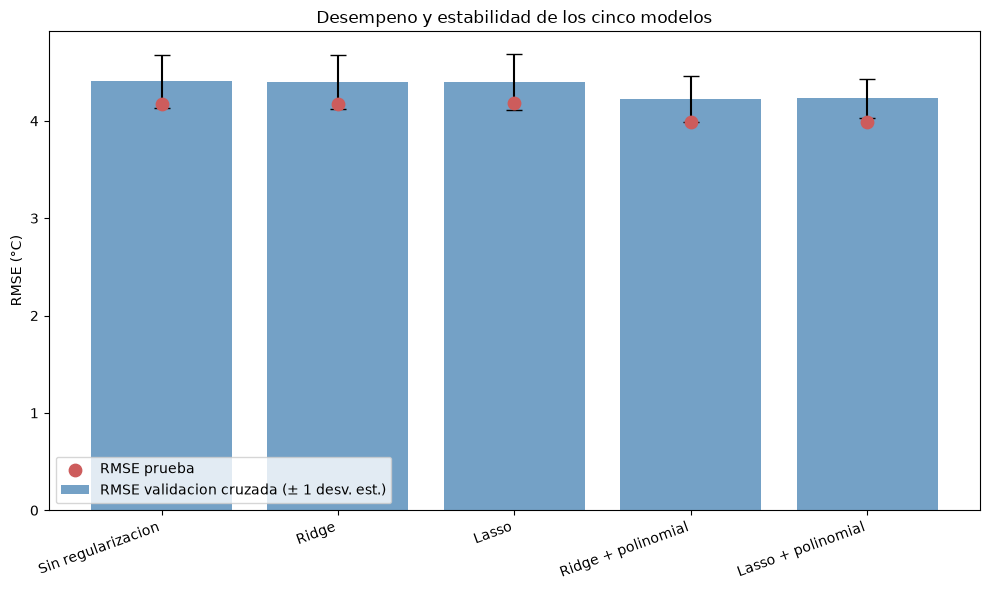

In [64]:
plt.figure(figsize=(10, 6))
x = np.arange(len(tabla_final))

plt.bar(x, tabla_final['RMSE_val_cv'], yerr=tabla_final['Desv_val_cv'], capsize=6,
        color='steelblue', alpha=0.75, label='RMSE validacion cruzada (± 1 desv. est.)')
plt.scatter(x, tabla_final['RMSE_test'], color='indianred', zorder=5, s=80, label='RMSE prueba')

plt.xticks(x, tabla_final.index, rotation=20, ha='right')
plt.ylabel('RMSE (°C)')
plt.title('Desempeno y estabilidad de los cinco modelos')
plt.legend()
plt.tight_layout()
plt.show()

## 5.3 Selección del modelo final

El gráfico permite observar que en los cinco modelos el punto de
prueba cae por debajo del techo de su propia barra de error, es decir, dentro del
rango que la validación cruzada anticipaba. Ninguna de las mejoras que se han visto en
el laboratorio es un espejismo del conjunto de prueba en particular.

Sobre cuál elegir, los tres criterios no apuntan al mismo modelo si se miran por
separado:

| Criterio | Gana |
|---|---|
| RMSE de prueba (más bajo) | Lasso + polinomial (3,9864 vs 3,9898 de Ridge + polinomial) |
| RMSE de validación cruzada (más bajo en promedio) | Ridge + polinomial (4,2203 vs 4,2309 de Lasso + polinomial) |
| Estabilidad (menor CV %) | Lasso + polinomial, y por bastante (4,76% vs 5,61% de Ridge + polinomial) |

Las dos primeras diferencias son de centésimas de grado, muy por debajo de la
desviación estándar de cualquiera de los dos (0,20-0,24), así que no alcanzan para
decidir nada por sí solas. La tercera sí es una diferencia real: el CV% de
Lasso+polinomial no es solo el más bajo entre los dos modelos polinomiales, es el más
bajo de los cinco modelos del laboratorio, incluyendo los tres que no tienen expansión
polinomial (6,21% - 6,48%). Es decir, el modelo con más parámetros de todos (1.559
coeficientes posibles) terminó siendo el más consistente entre pliegues, no el menos.

La razón aparece en la columna de coeficientes activos: Lasso+polinomial dejó
únicamente 117 de los 1.559 coeficientes distintos de cero, un 92,5% en cero. Frente a
Ridge+polinomial, que usa los 1.559 sin anular ninguno, Lasso+polinomial llega
prácticamente al mismo desempeño con una fracción del modelo. Esto también es más
agresivo que lo que Lasso hizo sin expansión polinomial en la Actividad 3, donde anuló
10 de 39 (conservó el 74%): con muchas más variables redundantes disponibles, el mismo
mecanismo de selección automática actúa con más fuerza, y es consistente con lo que ya
se había observado en la Actividad 4 sobre el alpha óptimo bajando al subir el grado.

Con esos tres criterios, el modelo final del laboratorio es **Lasso + polinomial**
(grado 3, alpha=0,001, `MinMaxScaler`):

- Empata en desempeño con el mejor de los cinco (RMSE de prueba 3,9864 °C, R² 0,7869),
  una mejora de 0,19 °C y casi 2 puntos de R² sobre el modelo lineal de referencia del
  Laboratorio 1 (RMSE 4,1761, R² 0,7661).
- Es el más estable entre pliegues de los cinco modelos evaluados, con el CV% más
  bajo (4,76%).
- Logra ese desempeño con selección automática de variables: 117 coeficientes activos
  de 1.559 posibles, bastante más compacto que la alternativa de desempeño equivalente
  (Ridge+polinomial, que usa los 1.559).

Para AlpesPlanck esto importa más allá de la cifra de RMSE: un sistema de alerta
temprana necesita comportarse igual de bien sin importar qué días le toquen, y eso es
justo lo que mide la estabilidad entre pliegues. Un modelo que gana por una centésima
de grado en promedio pero varía más de un período a otro es una apuesta peor para un
uso operativo que uno ligeramente más conservador en el promedio pero más consistente,
que es exactamente el perfil de Lasso+polinomial frente a Ridge+polinomial.

# Actividad 6: Intervalos de confianza por bootstrap

Todas las métricas reportadas hasta ahora son puntos: un RMSE de 3,9864, un R² de
0,7869. Pero esos números salen de un solo conjunto de prueba de 598 filas, que es una
muestra entre muchas posibles de los días que AlpesPlanck podría observar. Si se
hubiera hecho la partición con otra semilla, el número habría sido parecido pero no
igual. El bootstrap sirve para cuantificar esa incertidumbre sin necesitar más datos:
remuestrea el conjunto de prueba que ya se tiene, muchas veces, y mira qué tan distinto
sale el RMSE cada vez.

Esta actividad se aplica sobre el modelo final escogido en la Actividad 5,
Lasso + polinomial (grado 3, alpha=0,001, `MinMaxScaler`), que es el que efectivamente
se recomienda para AlpesPlanck.

## 6.1 Remuestreo bootstrap sobre el conjunto de prueba

El procedimiento remuestrea con reemplazo las filas de `X_test`/`y_test` -- nunca las
de entrenamiento -- y evalúa el modelo final, que ya está ajustado y no se vuelve a
entrenar en cada iteración. La razón de remuestrear el conjunto de prueba y no
reentrenar el modelo en cada vuelta es que lo que se quiere medir es la incertidumbre
de la estimación del desempeño (qué tan bien se conoce el RMSE con los datos de prueba
disponibles), no la variabilidad del proceso de entrenamiento, que ya se caracterizó
por separado con la desviación estándar de la validación cruzada en la Actividad 5.

Se usan 1.000 iteraciones, el doble del mínimo de 500 que pide el enunciado, y
`resample(..., random_state=i)` para que cada muestra sea distinta pero el notebook
completo sea reproducible.

In [68]:
modelo_final = best_polinomial_lasso
n_iteraciones = 1000

rmse_boot = np.empty(n_iteraciones)
mae_boot = np.empty(n_iteraciones)
r2_boot = np.empty(n_iteraciones)

for i in range(n_iteraciones):
    X_re, y_re = resample(X_test, y_test, random_state=i)
    y_pred_re = modelo_final.predict(X_re)
    rmse_boot[i] = np.sqrt(mean_squared_error(y_re, y_pred_re))
    mae_boot[i] = mean_absolute_error(y_re, y_pred_re)
    r2_boot[i] = r2_score(y_re, y_pred_re)

print(f"Bootstrap completado: {n_iteraciones} remuestreos sobre {len(X_test)} filas de prueba")
print(f"RMSE  -> media {rmse_boot.mean():.4f}, desv. est. {rmse_boot.std():.4f}")
print(f"MAE   -> media {mae_boot.mean():.4f}, desv. est. {mae_boot.std():.4f}")
print(f"R2    -> media {r2_boot.mean():.4f}, desv. est. {r2_boot.std():.4f}")

Bootstrap completado: 1000 remuestreos sobre 599 filas de prueba
RMSE  -> media 3.9867, desv. est. 0.1193
MAE   -> media 3.1712, desv. est. 0.1003
R2    -> media 0.7865, desv. est. 0.0148


## 6.2 Intervalos de confianza al 95%

El intervalo se calcula con el método percentil: se ordenan los 1.000 valores de cada
métrica y se toman los percentiles 2,5 y 97,5, que dejan el 95% central de la
distribución bootstrap en el medio. Se compara contra la estimación puntual original
(la que ya se reportó en las Actividades 4 y 5, calculada sobre el conjunto de prueba
completo, sin remuestrear).

In [66]:
tabla_ic = pd.DataFrame({
    'Estimacion puntual': [metricas_polinomial_lasso.loc['Prueba', 'RMSE'],
                           metricas_polinomial_lasso.loc['Prueba', 'MAE'],
                           metricas_polinomial_lasso.loc['Prueba', 'R2']],
    'Media bootstrap': [rmse_boot.mean(), mae_boot.mean(), r2_boot.mean()],
    'Desv. est. bootstrap': [rmse_boot.std(), mae_boot.std(), r2_boot.std()],
    'IC 95% inferior': [np.percentile(rmse_boot, 2.5), np.percentile(mae_boot, 2.5), np.percentile(r2_boot, 2.5)],
    'IC 95% superior': [np.percentile(rmse_boot, 97.5), np.percentile(mae_boot, 97.5), np.percentile(r2_boot, 97.5)],
}, index=['RMSE', 'MAE', 'R2'])

print("=== Intervalos de confianza al 95% (bootstrap, 1000 iteraciones) ===")
print(tabla_ic.round(4).to_string())

=== Intervalos de confianza al 95% (bootstrap, 1000 iteraciones) ===
      Estimacion puntual  Media bootstrap  Desv. est. bootstrap  IC 95% inferior  IC 95% superior
RMSE              3.9864           3.9867                0.1193           3.7585           4.2458
MAE               3.1719           3.1712                0.1003           2.9810           3.3825
R2                0.7869           0.7865                0.0148           0.7575           0.8148


## 6.3 Distribución del error

El histograma muestra la distribución completa de los 1.000 valores de RMSE, con la
estimación puntual y los límites del intervalo de confianza marcados como líneas
verticales, para ver de un vistazo qué tan concentrada o dispersa es la distribución
alrededor del valor que se ha estado reportando.

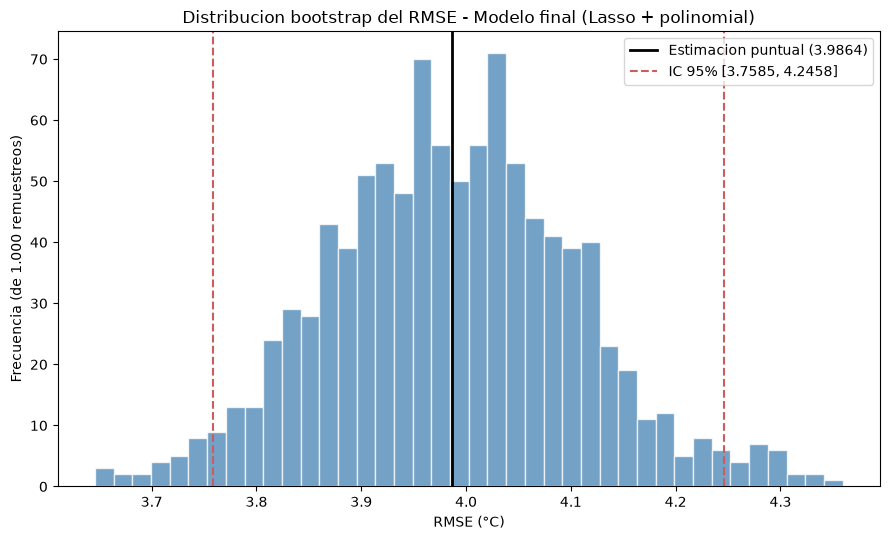

In [67]:
plt.figure(figsize=(9, 5.5))
plt.hist(rmse_boot, bins=40, color='steelblue', alpha=0.75, edgecolor='white')
plt.axvline(metricas_polinomial_lasso.loc['Prueba', 'RMSE'], color='black', linestyle='-', linewidth=2,
            label=f"Estimacion puntual ({metricas_polinomial_lasso.loc['Prueba', 'RMSE']:.4f})")
plt.axvline(np.percentile(rmse_boot, 2.5), color='indianred', linestyle='--', linewidth=1.5,
            label=f"IC 95% [{np.percentile(rmse_boot, 2.5):.4f}, {np.percentile(rmse_boot, 97.5):.4f}]")
plt.axvline(np.percentile(rmse_boot, 97.5), color='indianred', linestyle='--', linewidth=1.5)
plt.xlabel('RMSE (°C)')
plt.ylabel('Frecuencia (de 1.000 remuestreos)')
plt.title('Distribucion bootstrap del RMSE - Modelo final (Lasso + polinomial)')
plt.legend()
plt.tight_layout()
plt.show()

## 6.4 Interpretación

Lo primero que confirma el bootstrap es que la estimación puntual no está sesgada: la
media de los 1.000 RMSE (3,9867) prácticamente coincide con el RMSE original sobre el
conjunto de prueba completo (3,9864). El histograma es unimodal y razonablemente
simétrico alrededor de ese valor, sin colas largas ni señales de que unos pocos días
atípicos estén dominando el resultado.

El intervalo de confianza sí es más ancho de lo que uno esperaría mirando solo el
punto: RMSE entre 3,76 y 4,25 °C, un rango de casi medio grado. Puesto en otros
términos, reportar "RMSE = 3,99 °C" sin el intervalo transmite una precisión que en
realidad no se tiene con un conjunto de prueba de 599 filas; lo honesto es reportar el
rango completo.

Vale la pena comparar esta desviación (0,1193) con la desviación entre pliegues de la
Actividad 5 (0,2013): son números del mismo orden pero no miden lo mismo. La de la
validación cruzada viene de solo 5 particiones distintas de entrenamiento y refleja
qué tan sensible es el ajuste del modelo a qué filas le tocan para entrenar. La del
bootstrap viene de 1.000 remuestreos de un conjunto de prueba fijo, con el modelo ya
entrenado y sin volver a ajustarlo, y refleja la incertidumbre propia de medir el
desempeño con una muestra de tamaño finito. Que sean parecidas es una buena señal: las
dos fuentes de variabilidad, la del entrenamiento y la de la medición, están en un
rango similar y ninguna domina desproporcionadamente a la otra.

Un punto que conviene decir con honestidad: el RMSE de 4,1761 del modelo sin
regularizar (el que ya se tenía desde el Laboratorio 1) cae *dentro* del intervalo de
confianza del modelo final, cerca del límite superior. Esto no invalida la elección de
la Actividad 5, la mejora fue consistente en validación cruzada, en prueba y en
estabilidad, tres evidencias independientes que apuntan en la misma dirección, pero
sí significa que la magnitud exacta de esa mejora (los 0,19 °C que se han citado varias
veces) tiene incertidumbre de muestreo, y no se le puede prometer a AlpesPlanck como una
ganancia garantizada de exactamente esa cifra en cualquier conjunto de días nuevo. Lo
que sí se puede afirmar con más confianza es la dirección del efecto y un rango
razonable para el error esperado: alrededor de 4 °C, con un 95% de probabilidad de estar
entre 3,76 y 4,25 °C.